In [66]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras import backend as K

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [68]:
(x_train, y_tran), (x_test, y_test) = mnist.load_data()

In [69]:
print("x_train [shape %s] sample patch\n" %(str(x_train.shape)), x_train[1,15:20,5:10])

x_train [shape (60000, 28, 28)] sample patch
 [[  0  76 246 252 112]
 [  0  85 252 230  25]
 [  0  85 252 223   0]
 [  0  85 252 145   0]
 [  0  86 253 225   0]]


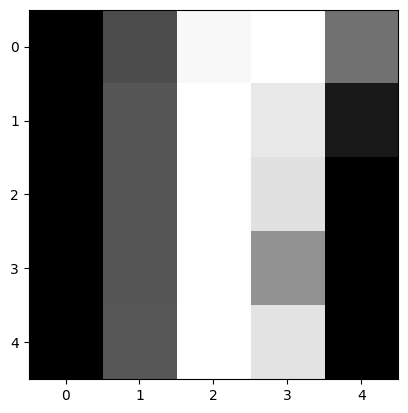

In [70]:
import matplotlib.pyplot as plt

plt.imshow(x_train[1, 15:20, 5:10], cmap='gray')
plt.show()

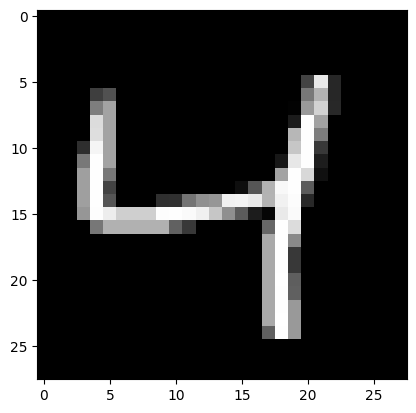

In [71]:
plt.imshow(x_train[2], cmap='gray')
plt.show()

In [72]:
import tensorflow as tf
# Load and preprocess the MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
 
 

In [73]:
#scale
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
#flatten
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)
#one hot encoding labels
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(200, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dense(100,activation='relu'),
    tf.keras.layers.Dense(60,activation='relu'),
    tf.keras.layers.Dense(30,activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 200)            │       157,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 60)             │         6,060 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 10)             │           310 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,300 (723.83 KB)

 Trainable params: 185,300 (723.83 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics= ['accuracy'])

In [75]:
history = model.fit(x_train, y_train, epochs = 10, batch_size=64, validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9087 - loss: 0.3102 - val_accuracy: 0.9491 - val_loss: 0.1603
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9649 - loss: 0.1159 - val_accuracy: 0.9668 - val_loss: 0.1096
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9767 - loss: 0.0777 - val_accuracy: 0.9639 - val_loss: 0.1251
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9804 - loss: 0.0628 - val_accuracy: 0.9637 - val_loss: 0.1206
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9852 - loss: 0.0475 - val_accuracy: 0.9715 - val_loss: 0.1015
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9875 - loss: 0.0392 - val_accuracy: 0.9732 - val_loss: 0.0995
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9893 - loss: 0.0330 - val_accuracy: 0.9729 - val_loss: 0.1034
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9914 - loss: 0.0267 - val_accuracy: 0.

In [76]:
test_loss, test_acc = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 946us/step - accuracy: 0.9739 - loss: 0.1053


In [77]:
print(test_loss)
print(test_acc)


0.10525531321763992
0.9739000201225281


In [78]:
import numpy as np 


In [79]:
def get_random_ind(total_images, num_images):
    indices = np.random.choice(total_images, num_images, replace=False)
    return indices

In [80]:
predictions = model.predict(x_test)
x_test_images = x_test.reshape(-1, 28, 28)
prediction_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 799us/step


In [81]:
num_images_to_show = 5
random_indices = get_random_ind(len(x_test_images), num_images_to_show)
def plot_images(images, labels, predictions):
    plt.figure(figsize=(10, 9))
    for i in range(len(images)):
        plt.subplot(1, len(images), i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(f"Actual: {labels[i]} \n predicted: {predictions[i]}")
        plt.axis('off')
    plt.show()

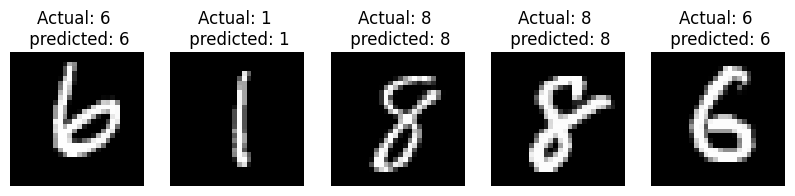

In [82]:
plot_images(
    x_test_images[random_indices],
    true_classes[random_indices],
    prediction_classes[random_indices]
)

In [83]:
import tensorflow as tf
from tensorflow.keras.callbacks import TensorBoard
list_activations = ['sigmoid', 'relu, tanh']
list_optmizers = ['adam', 'rmsprop']

NAME = 'mnist-28-28-v1'
tensorboard = TensorBoard(log_dir='logs/{}'.format(NAME))
# Load and preprocess the MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
 
x_train = x_train.astype('float32') / 255.0# scaling min max scaler
x_test = x_test.astype('float32') /255.0
#flatten the images (28*28 into 784)
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)
#one - hot encoding labels
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

i = 1
for activation in list_activations:
    for optmizer in list_optmizers:

        model = tf.keras.Sequential([
            tf.keras.layers.Dense(200, activation = 'relu', input_shape =(784,)),
            tf.keras.layers.Dense(100, activation = 'relu'),
            tf.keras.layers.Dense(60, activation = 'relu'),
            tf.keras.layers.Dense(30, activation = 'relu'),
            tf.keras.layers.Dense(10, activation = 'softmax')
        ])
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])
        historty = model.fit(x_train,y_train, epochs =10, batch_size=64, validation_split=0.2, callbacks=[tensorboard])
        test_loss, test_acc = model.evaluate(x_test, y_test)
        print(f'Test accuracy: {test_acc}')
        #
 

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6804 - loss: 0.9507 - val_accuracy: 0.8270 - val_loss: 0.5605
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8579 - loss: 0.4812 - val_accuracy: 0.8817 - val_loss: 0.3984
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8900 - loss: 0.3731 - val_accuracy: 0.9085 - val_loss: 0.3180
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9122 - loss: 0.2980 - val_accuracy: 0.9227 - val_loss: 0.2579
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9273 - loss: 0.2438 - val_accuracy: 0.9345 - val_loss: 0.2167
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9393 - loss: 0.2011 - val_accuracy: 0.9417 - val_loss: 0.2019
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9475 - loss: 0.1740 - val_accuracy: 0.9467 - val_loss: 0.1747
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9538 - loss: 0.1543 - val_accuracy: 0.

In [84]:
%load_ext tensorboard
%tensorboard --logdir logs --port 6006

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 14060), started 0:08:45 ago. (Use '!kill 14060' to kill it.)